# Cleaning the dataset

In [1]:
# importing all the required libraries : 

import pandas as pd, numpy as np
 

In [2]:
df = pd.read_csv("bookscraper/books.csv")

df.head(5)

,title,category,price,rating,availability,description,UPC,reviews,url
0,In the Country We Love: My Family Divided,Nonfiction,£22.00,Four,In stock (16 available),The star of Orange is the New Black and Jane t...,b136b1b180ca753a,0,https://books.toscrape.com/catalogue/in-the-co...
1,Join,Science Fiction,£35.67,Five,In stock (16 available),What if you could live multiple lives simultan...,18ad3ed896c7ce05,0,https://books.toscrape.com/catalogue/join_902/...
2,Judo: Seven Steps to Black Belt (an Introducto...,Add a comment,£53.90,Two,In stock (16 available),"Displaying the most impressive throws, compell...",228f74b74f3a08ae,0,https://books.toscrape.com/catalogue/judo-seve...
3,"Layered: Baking, Building, and Styling Spectac...",Food and Drink,£40.11,One,In stock (16 available),It’s time to venture beyond vanilla and chocol...,7b75cc7f223791f4,0,https://books.toscrape.com/catalogue/layered-b...
4,Lumberjanes Vol. 3: A Terrible Plan (Lumberjan...,Sequential Art,£19.92,Two,In stock (16 available),This New York Times Bestselling series continu...,57e5a4d515c8ce44,0,https://books.toscrape.com/catalogue/lumberjan...


In [3]:
# Remove leading and trailing spaces from all text columns
text_columns = df.select_dtypes(include="object").columns

for col in text_columns:
    df[col] = df[col].str.strip()

# dropping the duplicates from UPC column : 
df = df.drop_duplicates(subset="UPC")

In [4]:
df.columns

Index(['title', 'category', 'price', 'rating', 'availability', 'description',
       'UPC', 'reviews', 'url'],
      dtype='object')

In [5]:
print(df.price.head(5))
# price column is a string type column , convert it to float type column : 

df.price = df.price.str.replace("£","", regex = False ).astype(float)

print(df.price.head(5))

0    £22.00
1    £35.67
2    £53.90
3    £40.11
4    £19.92
Name: price, dtype: object
0    22.00
1    35.67
2    53.90
3    40.11
4    19.92
Name: price, dtype: float64


In [6]:
print(df.rating.head(5))
# converting rating column to int type column :
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["rating"] = df["rating"].map(rating_map)

print(df.rating.head(5))

0    Four
1    Five
2     Two
3     One
4     Two
Name: rating, dtype: object
0    4
1    5
2    2
3    1
4    2
Name: rating, dtype: int64


In [7]:
print(df.availability.head(5))

# this column needs to be cleaned 
df["availability"] = (
    df["availability"]
    .str.split("\n")
    .str[0]
    .str.strip()
)
# extract the number of available books from the availability column 
# and create a new column called stock_count
df["stock_count"] = (
    df["availability"]
    .str.extract(r"\((\d+) available\)")
    .astype(int)
)

print(df.availability.head(5))
print(df.stock_count.head(5))


0    In stock (16 available)
1    In stock (16 available)
2    In stock (16 available)
3    In stock (16 available)
4    In stock (16 available)
Name: availability, dtype: object
0    In stock (16 available)
1    In stock (16 available)
2    In stock (16 available)
3    In stock (16 available)
4    In stock (16 available)
Name: availability, dtype: object
0    16
1    16
2    16
3    16
4    16
Name: stock_count, dtype: int64


In [8]:
df.reviews.dtype
# this column doesn't need cleaning as it is already in int type 
# 

dtype('int64')

In [9]:
print(df.description.head(5))
print(df.url.head(5))
print(df.UPC.head(5))
# description, url and UPC seem clean

0    The star of Orange is the New Black and Jane t...
1    What if you could live multiple lives simultan...
2    Displaying the most impressive throws, compell...
3    It’s time to venture beyond vanilla and chocol...
4    This New York Times Bestselling series continu...
Name: description, dtype: object
0    https://books.toscrape.com/catalogue/in-the-co...
1    https://books.toscrape.com/catalogue/join_902/...
2    https://books.toscrape.com/catalogue/judo-seve...
3    https://books.toscrape.com/catalogue/layered-b...
4    https://books.toscrape.com/catalogue/lumberjan...
Name: url, dtype: object
0    b136b1b180ca753a
1    18ad3ed896c7ce05
2    228f74b74f3a08ae
3    7b75cc7f223791f4
4    57e5a4d515c8ce44
Name: UPC, dtype: object


In [10]:
# saving it all in a new file 
df.to_csv("books_cleaned.csv", index=False)

# EDA (Exploratory Data Analysis)

In [11]:
df.head(5)

,title,category,price,rating,availability,description,UPC,reviews,url,stock_count
0,In the Country We Love: My Family Divided,Nonfiction,22.00,4,In stock (16 available),The star of Orange is the New Black and Jane t...,b136b1b180ca753a,0,https://books.toscrape.com/catalogue/in-the-co...,16
1,Join,Science Fiction,35.67,5,In stock (16 available),What if you could live multiple lives simultan...,18ad3ed896c7ce05,0,https://books.toscrape.com/catalogue/join_902/...,16
2,Judo: Seven Steps to Black Belt (an Introducto...,Add a comment,53.90,2,In stock (16 available),"Displaying the most impressive throws, compell...",228f74b74f3a08ae,0,https://books.toscrape.com/catalogue/judo-seve...,16
3,"Layered: Baking, Building, and Styling Spectac...",Food and Drink,40.11,1,In stock (16 available),It’s time to venture beyond vanilla and chocol...,7b75cc7f223791f4,0,https://books.toscrape.com/catalogue/layered-b...,16
4,Lumberjanes Vol. 3: A Terrible Plan (Lumberjan...,Sequential Art,19.92,2,In stock (16 available),This New York Times Bestselling series continu...,57e5a4d515c8ce44,0,https://books.toscrape.com/catalogue/lumberjan...,16


In [12]:
# checking for all Missing descriptions in the dataset :
df.isnull().sum()

title           0
category        0
price           0
rating          0
availability    0
description     0
UPC             0
reviews         0
url             0
stock_count     0
dtype: int64

#### Creating new features to better understand the data :


In [13]:
# categorizing books into cheap , medium and expensive based on their price
df["price_band"] = pd.cut(
    df["price"],
    bins=[0, 20, 40, 100],
    labels=["Cheap", "Medium", "Expensive"]
)
print(df[["price", "price_band"]].head())
# a longer description might indicate a more detailed and informative book, 
# which could be a factor in its perceived value.
df["description_word_count"] = df["description"].str.split().str.len()
print(df[["description", "description_word_count"]].head())
# higher score = lower price
df["affordability_score"] = 100 - df["price"]
# a book might be recommended if its rating is more than 4 - 5 or 
# price is less than 40
df["recommended"] = (
    (df["rating"] >= 4) &
    (df["price"] < 40)
)

   price price_band
0  22.00     Medium
1  35.67     Medium
2  53.90  Expensive
3  40.11  Expensive
4  19.92      Cheap
                                         description  description_word_count
0  The star of Orange is the New Black and Jane t...                     276
1  What if you could live multiple lives simultan...                     291
2  Displaying the most impressive throws, compell...                     171
3  It’s time to venture beyond vanilla and chocol...                     166
4  This New York Times Bestselling series continu...                      47


In [14]:
df.head(5)

,title,category,price,rating,availability,description,UPC,reviews,url,stock_count,price_band,description_word_count,affordability_score,recommended
0,In the Country We Love: My Family Divided,Nonfiction,22.00,4,In stock (16 available),The star of Orange is the New Black and Jane t...,b136b1b180ca753a,0,https://books.toscrape.com/catalogue/in-the-co...,16,Medium,276,78.00,True
1,Join,Science Fiction,35.67,5,In stock (16 available),What if you could live multiple lives simultan...,18ad3ed896c7ce05,0,https://books.toscrape.com/catalogue/join_902/...,16,Medium,291,64.33,True
2,Judo: Seven Steps to Black Belt (an Introducto...,Add a comment,53.90,2,In stock (16 available),"Displaying the most impressive throws, compell...",228f74b74f3a08ae,0,https://books.toscrape.com/catalogue/judo-seve...,16,Expensive,171,46.10,False
3,"Layered: Baking, Building, and Styling Spectac...",Food and Drink,40.11,1,In stock (16 available),It’s time to venture beyond vanilla and chocol...,7b75cc7f223791f4,0,https://books.toscrape.com/catalogue/layered-b...,16,Expensive,166,59.89,False
4,Lumberjanes Vol. 3: A Terrible Plan (Lumberjan...,Sequential Art,19.92,2,In stock (16 available),This New York Times Bestselling series continu...,57e5a4d515c8ce44,0,https://books.toscrape.com/catalogue/lumberjan...,16,Cheap,47,80.08,False


In [15]:
#  Saving the cleaned ddataset :
df.to_csv("books_cleaned.csv", index=False)

#### Analysing the dataset : 

SUMMARY STATISTICS

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   title                   20 non-null     object 
 1   category                20 non-null     object 
 2   price                   20 non-null     float64
 3   rating                  20 non-null     int64  
 4   availability            20 non-null     object 
 5   description             20 non-null     object 
 6   UPC                     20 non-null     object 
 7   reviews                 20 non-null     int64  
 8   url                     20 non-null     object 
 9   stock_count             20 non-null     int64  
 10  price_band              20 non-null     object 
 11  description_word_count  20 non-null     int64  
 12  affordability_score     20 non-null     float64
 13  recommended             20 non-null     bool   
dtypes: bool(1)

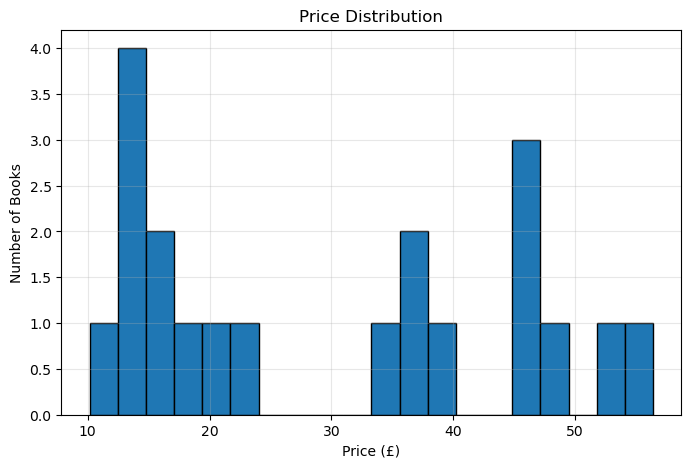

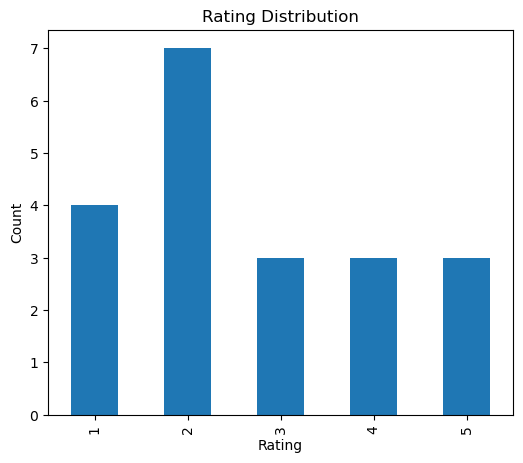

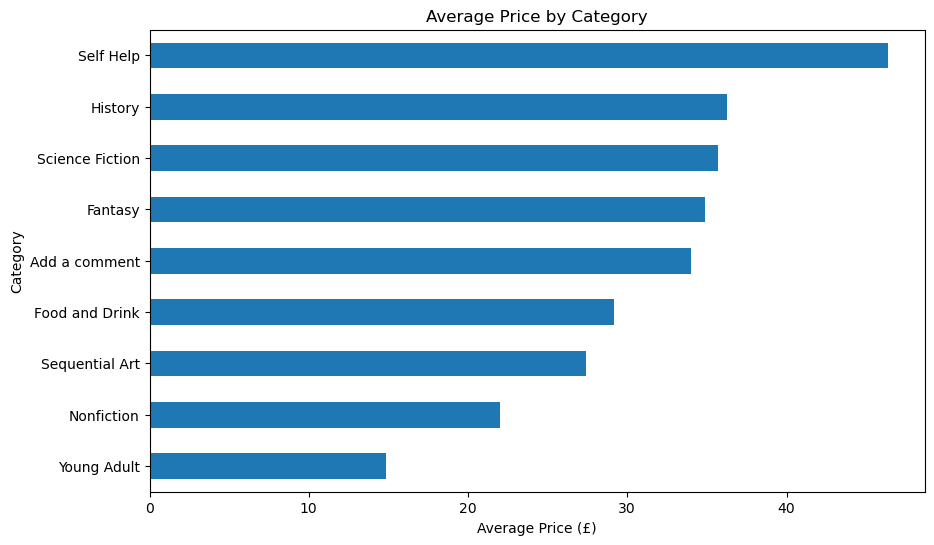

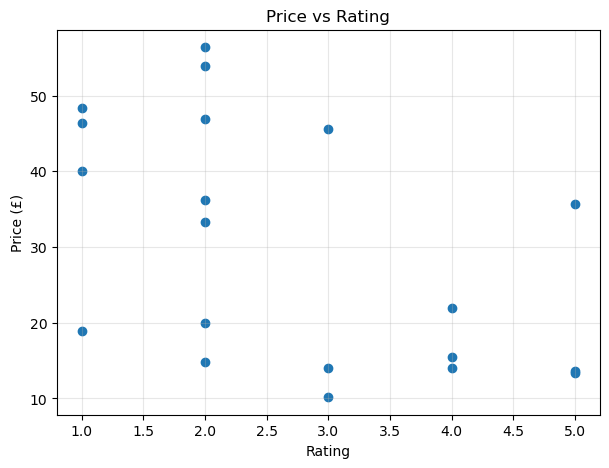

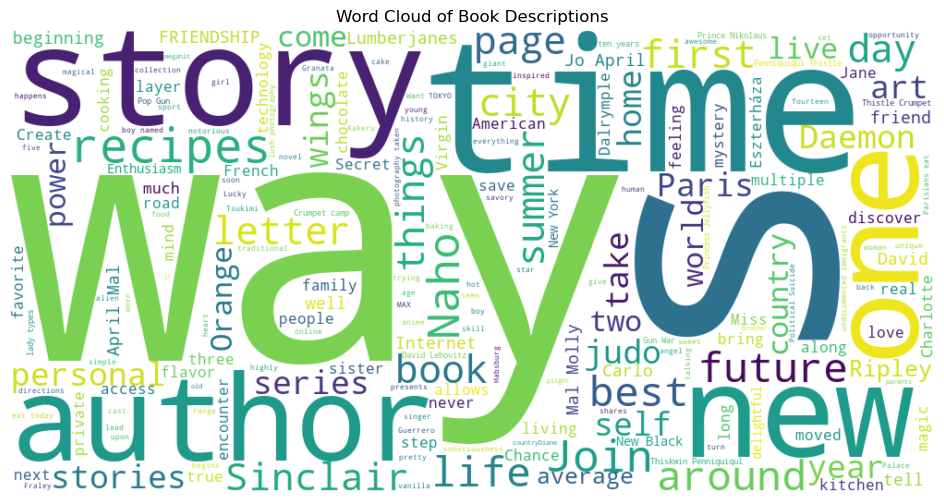

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# Load cleaned dataset
df = pd.read_csv("books_cleaned.csv")

# -----------------------------
# SUMMARY STATISTICS
# -----------------------------
print("="*50)
print("SUMMARY STATISTICS")
print("="*50)

print("\nDataset Info:")
print(df.info())

print("\nNumerical Statistics:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBooks per Category:")
print(df["category"].value_counts())

print("\nHighly Rated Books (Rating = 5):")
print(df[df["rating"] == 5][["title", "category", "price"]])

print("\nAverage Stock by Category:")
print(df.groupby("category")["stock_count"].mean())

# -----------------------------
# PLOT 1 : PRICE DISTRIBUTION
# -----------------------------
plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=20, edgecolor="black")
plt.title("Price Distribution")
plt.xlabel("Price (£)")
plt.ylabel("Number of Books")
plt.grid(alpha=0.3)
plt.show()

# -----------------------------
# PLOT 2 : RATING DISTRIBUTION
# -----------------------------
plt.figure(figsize=(6,5))
df["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

# -----------------------------
# PLOT 3 : AVERAGE PRICE BY CATEGORY
# -----------------------------
avg_price = df.groupby("category")["price"].mean().sort_values()

plt.figure(figsize=(10,6))
avg_price.plot(kind="barh")
plt.title("Average Price by Category")
plt.xlabel("Average Price (£)")
plt.ylabel("Category")
plt.show()

# -----------------------------
# PLOT 4 : PRICE vs RATING
# -----------------------------
plt.figure(figsize=(7,5))
plt.scatter(df["rating"], df["price"])
plt.title("Price vs Rating")
plt.xlabel("Rating")
plt.ylabel("Price (£)")
plt.grid(alpha=0.3)
plt.show()

# -----------------------------
# WORD CLOUD
# -----------------------------
text = " ".join(df["description"].astype(str))

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Book Descriptions")
plt.show()



In [24]:
# -----------------------------
# ADDITIONAL ANALYSIS
# -----------------------------
print("\nAverage Price by Category")
print(df.groupby("category")["price"].mean())

print("\nAverage Price by Rating")
print(df.groupby("rating")["price"].mean())

print("\nTop 10 Most Expensive Books")
print(df.nlargest(10, "price")[["title","category","price"]])

print("\nTop 10 Cheapest Books")
print(df.nsmallest(10, "price")[["title","category","price"]])

print("\nTop Categories by Average Stock")
print(df.groupby("category")["stock_count"].mean().sort_values(ascending=False))

print("\nPotential Outliers (Price > £50)")
print(df[df["price"] > 50][["title","price","category"]])


Average Price by Category
category
Add a comment      33.985000
Fantasy            34.870000
Food and Drink     29.166667
History            36.280000
Nonfiction         22.000000
Science Fiction    35.670000
Self Help          46.350000
Sequential Art     27.378750
Young Adult        14.860000
Name: price, dtype: float64

Average Price by Rating
rating
1    38.460000
2    37.377143
3    23.280000
4    17.153333
5    20.873333
Name: price, dtype: float64

Top 10 Most Expensive Books
                                                title         category  price
8                                   Masks and Shadows          Fantasy  56.40
2   Judo: Seven Steps to Black Belt (an Introducto...    Add a comment  53.90
13  orange: The Complete Collection 1 (orange: The...   Sequential Art  48.41
6   Lumberjanes, Vol. 2: Friendship to the Max (Lu...   Sequential Art  46.91
12  Online Marketing for Busy Authors: A Step-By-S...        Self Help  46.35
5   Lumberjanes, Vol. 1: Beware the Kitten 

##### Insights :
1. The collection seems to contain cheaper books relatively more than the expensive or the medium ones . 

2. Majority of the books are rated 2 .
3. Self-help category books are priced higher on an average compared to books of the other categories 
4. Here lesser rated books are priced more than high rated books , thus showing that high prices doesnt mean better quality . 
5. The word cloud seems to be dominated by words like 'way' , 'story' , 'time' , 'author', and 'new' . However these words dont seem to convey much meaning , but words like 'life' , live' , 'day' , recipes' , 'wings' 'power' are showing up indicating amny books in the lot has a theme revolving around life , freedom and maybe cooking . 